In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [2]:
X, y = make_regression(n_samples= 100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

In [3]:
X,y

(array([[-0.71239066],
        [-0.43714566],
        [-0.45375238],
        [ 0.95283061],
        [ 0.23785784],
        [ 0.86121137],
        [-0.24332625],
        [ 0.18494595],
        [-0.72099967],
        [-0.42989708],
        [ 2.01522083],
        [ 0.39724133],
        [ 0.20780005],
        [-0.23242587],
        [-0.76862702],
        [ 0.45315861],
        [ 0.63988397],
        [ 0.3595323 ],
        [-1.61510796],
        [ 1.74924179],
        [-0.78898902],
        [-0.51196509],
        [-0.92833523],
        [ 2.15038297],
        [-0.2073497 ],
        [-1.63909341],
        [-0.33861825],
        [-0.32212366],
        [-0.48137142],
        [-0.52316421],
        [ 0.72196506],
        [ 0.76591105],
        [ 0.45348104],
        [-1.26160595],
        [-2.18711527],
        [-1.18541881],
        [ 0.21745166],
        [ 1.33031692],
        [-1.08718159],
        [ 0.56226171],
        [-1.51284512],
        [-0.00238903],
        [-0.27813452],
        [ 0

In [4]:
import pandas as pd

In [5]:
df = pd.DataFrame(X, columns=["X_data"])
df["target"] = y

In [6]:
df

,X_data,target
0,-0.712391,-34.319881
1,-0.437146,-9.421210
2,-0.453752,-19.088188
3,0.952831,20.437212
4,0.237858,27.755966
...,...,...
95,-0.314858,-27.979066
96,1.849613,64.179470
97,-1.120507,-60.715439
98,-0.332676,22.233365


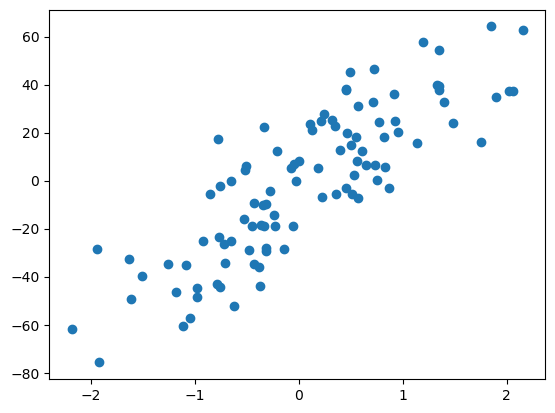

In [7]:
plt.scatter(X,y)

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
lr = LinearRegression()

In [12]:
lr.fit(X_train, y_train)

LinearRegression()

In [13]:
lr.coef_

array([28.16404017])

In [14]:
lr.intercept_

np.float64(-2.7130725669241036)

In [15]:
from sklearn.metrics import r2_score

In [16]:
y_pred = lr.predict(X_test)
y_pred

array([ 20.68858776, -24.53062886,  13.1389669 ,  23.26386508,
        30.82199856,  13.12248871, -28.85874316,  11.77250597,
        54.0436877 , -22.77687179, -48.20103812,  17.62038031,
        18.516034  , -38.24499309,   7.10915317,   3.98596515,
        12.2797131 , -30.43101636,   3.13941648,  18.85807699])

In [17]:
r2_score(y_test, y_pred)

0.6186926408914155

In [24]:
class GDRegressor:
    def __init__(self, learning_rate, epochs):
        self.m = 28.16404017
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X,y):
        for i in range(self.epochs):
            loss_slope_b = -2*np.sum(y - self.m*X.ravel() - self.b)
            self.b = self.b - (self.lr*loss_slope_b)

            print(f"m = {self.m}, b = {self.b}")

    def predict(self, X):
        return self.m * X + self.b

In [26]:
gd = GDRegressor(0.001, 100)
gd.fit(X_train, y_train)

m = 28.16404017, b = -101.23409161070306
m = 28.16404017, b = -85.47072856369363
m = 28.16404017, b = -72.2295036042057
m = 28.16404017, b = -61.10687463823585
m = 28.16404017, b = -51.76386630682118
m = 28.16404017, b = -43.91573930843285
m = 28.16404017, b = -37.323312629786656
m = 28.16404017, b = -31.78567421972385
m = 28.16404017, b = -27.134057955271096
m = 28.16404017, b = -23.226700293130783
m = 28.16404017, b = -19.94451985693292
m = 28.16404017, b = -17.187488290526716
m = 28.16404017, b = -14.871581774745502
m = 28.16404017, b = -12.926220301489284
m = 28.16404017, b = -11.29211666395406
m = 28.16404017, b = -9.919469608424471
m = 28.16404017, b = -8.766446081779618
m = 28.16404017, b = -7.797906319397941
m = 28.16404017, b = -6.984332918997333
m = 28.16404017, b = -6.300931262660821
m = 28.16404017, b = -5.726873871338151
m = 28.16404017, b = -5.244665662627109
m = 28.16404017, b = -4.839610767309833
m = 28.16404017, b = -4.499364655243322
m = 28.16404017, b = -4.2135579211

In [28]:
class GDRegressor:
    def __init__(self, learning_rate, epochs):
        self.m = 1
        self.b = 0
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X,y):
        for i in range(self.epochs):
            loss_slope_b = -2*np.sum(y - self.m*X.ravel() - self.b)
            self.b = self.b - (self.lr*loss_slope_b)

            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)* X.ravel())
            self.m = self.m - (self.lr * loss_slope_m)
                                       
            print(f"m = {self.m}, b = {self.b}")

    def predict(self, X):
        return self.m * X + self.b

In [29]:
gd = GDRegressor(0.001,50)
gd.fit(X_train,y_train)

m = 4.7909350273239575, b = -0.3281519835128252
m = 8.052652745047903, b = -0.6185842782013167
m = 10.859058782322768, b = -0.8752680892923517
m = 13.273733539942205, b = -1.1018274607779375
m = 15.351375390498015, b = -1.3015545528714103
m = 17.13904204752514, b = -1.4774281035443697
m = 18.6772183470591, b = -1.632133777551453
m = 20.000734729969306, b = -1.7680854239541308
m = 21.13955731266365, b = -1.8874465145174149
m = 22.119467509529063, b = -1.992151233235078
m = 22.96264665594444, b = -2.083924842055115
m = 23.688178918424313, b = -2.1643030681160966
m = 24.312483919036076, b = -2.234650350372867
m = 24.849688902224585, b = -2.2961768539952967
m = 25.31194889707604, b = -2.349954213912077
m = 25.709722145479976, b = -2.3969300080188094
m = 26.052007049626773, b = -2.4379409888413215
m = 26.346546017614614, b = -2.473725122226962
m = 26.600000833692864, b = -2.5049324948421825
m = 26.818103532692735, b = -2.532135160413624
m = 27.005786201748407, b = -2.555835998980185
m = 27.

In [30]:
import numpy as np

# 2D array
X = np.array([[1, 2, 3],
              [4, 5, 6]])

print("Original array:")
print(X)
print("Shape:", X.shape)

# Flatten using ravel
X_flat = X.ravel()

print("\nFlattened array:")
print(X_flat)
print("Shape:", X_flat.shape)


Original array:
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)

Flattened array:
[1 2 3 4 5 6]
Shape: (6,)
